In [13]:
import os, sys, json
import polars as pl
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
sns.set_style('whitegrid')
from BigEDA.plots import boxplot_matrix, histogram_matrix, barplot_matrix
from BigEDA.descriptive import outliers_table

In [14]:
DATA_ID = 'kc_houses' 
formatted_data_name = DATA_ID.replace('_', ' ').capitalize()

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

from src.utils.simulations_utils import generate_simulation
from config.config_simulations import SIMULATION_CONFIGS
from config.config_experiment_5 import CONFIG_EXPERIMENT

config_experiment = CONFIG_EXPERIMENT[DATA_ID]

In [15]:
data_filename = f'{DATA_ID}_processed.parquet'
metadata_filename = f'metadata_{DATA_ID}.json'
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
metadata_path = os.path.join(processed_data_dir, metadata_filename)
processed_data_path = os.path.join(processed_data_dir, data_filename)
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)
data = pl.read_parquet(processed_data_path)
quant_predictors = metadata['quant_predictors']
binary_predictors = metadata['binary_predictors']
multiclass_predictors = metadata['multiclass_predictors']
cat_predictors = binary_predictors + multiclass_predictors
X = data[quant_predictors + binary_predictors + multiclass_predictors]
y = data[metadata['response']]

In [16]:
X.head()

bedrooms,bathrooms,sqft_living,sqft_lot,condition,sqft_above,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15,view,grade,floors
i64,f64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64
3,1.0,1180,5650,3,1180,0,1955,47.5112,-122.257,1340,5650,0,4,1
3,2.25,2570,7242,3,2170,400,1951,47.721,-122.319,1690,7639,0,4,2
2,1.0,770,10000,3,770,0,1933,47.7379,-122.233,2720,8062,0,3,1
4,3.0,1960,5000,5,1050,910,1965,47.5208,-122.393,1360,5000,0,4,1
3,2.0,1680,8080,3,1680,0,1987,47.6168,-122.045,1800,7503,0,5,1


In [17]:
# Proportion of individuals per cluster/group
unique_values, counts = np.unique(y, return_counts=True)
prop_clusters = counts/len(y)
prop_clusters = {k: v for k, v in zip(unique_values, prop_clusters)}
print(f'prop_clusters: {prop_clusters}')

prop_clusters: {0: 0.09607815900356531, 1: 0.8038616474510348, 2: 0.10006019354539983}


In [18]:
# Outliers information
outliers_table(X, auto=False, col_names=quant_predictors, h=1.5)

quant_variables,lower_bound,upper_bound,n_outliers,n_not_outliers,prop_outliers,prop_not_outliers
str,f64,f64,i64,i64,f64,f64
"""bedrooms""",1.5,5.5,530,21067,0.02454,0.97546
"""bathrooms""",0.625,3.625,561,21036,0.025976,0.974024
"""sqft_living""",-250.0,4230.0,571,21026,0.026439,0.973561
"""sqft_lot""",-3427.5,19152.5,2419,19178,0.112006,0.887994
"""condition""",1.5,5.5,29,21568,0.001343,0.998657
…,…,…,…,…,…,…
"""yr_built""",1882.0,2066.0,0,21597,0.0,1.0
"""lat""",47.16075,47.98835,2,21595,0.000093,0.999907
"""long""",-122.6325,-121.8205,255,21342,0.011807,0.988193


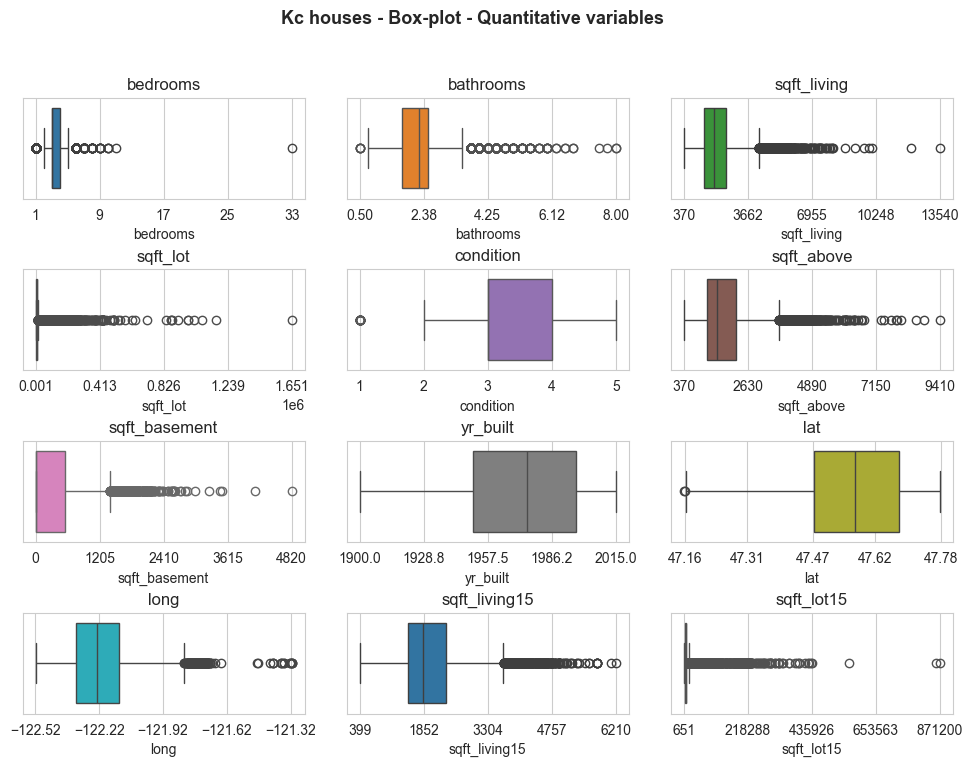

In [27]:
# Boxplot after outliers contamination
boxplot_matrix(X, 
               n_cols=3, 
               title=f'{formatted_data_name} - Box-plot - Quantitative variables', 
               figsize=(12, 8), 
               quant_col_names=quant_predictors, 
               n_xticks=5, 
               title_fontsize=13, 
               save=False, 
               file_name='', 
               x_rotation=0, 
               title_height=0.99,
               style='whitegrid', 
               hspace=0.7, 
               wspace=0.15, 
               title_weight='bold',
               subtitles_fontsize=12, 
               xlabel_size=10)

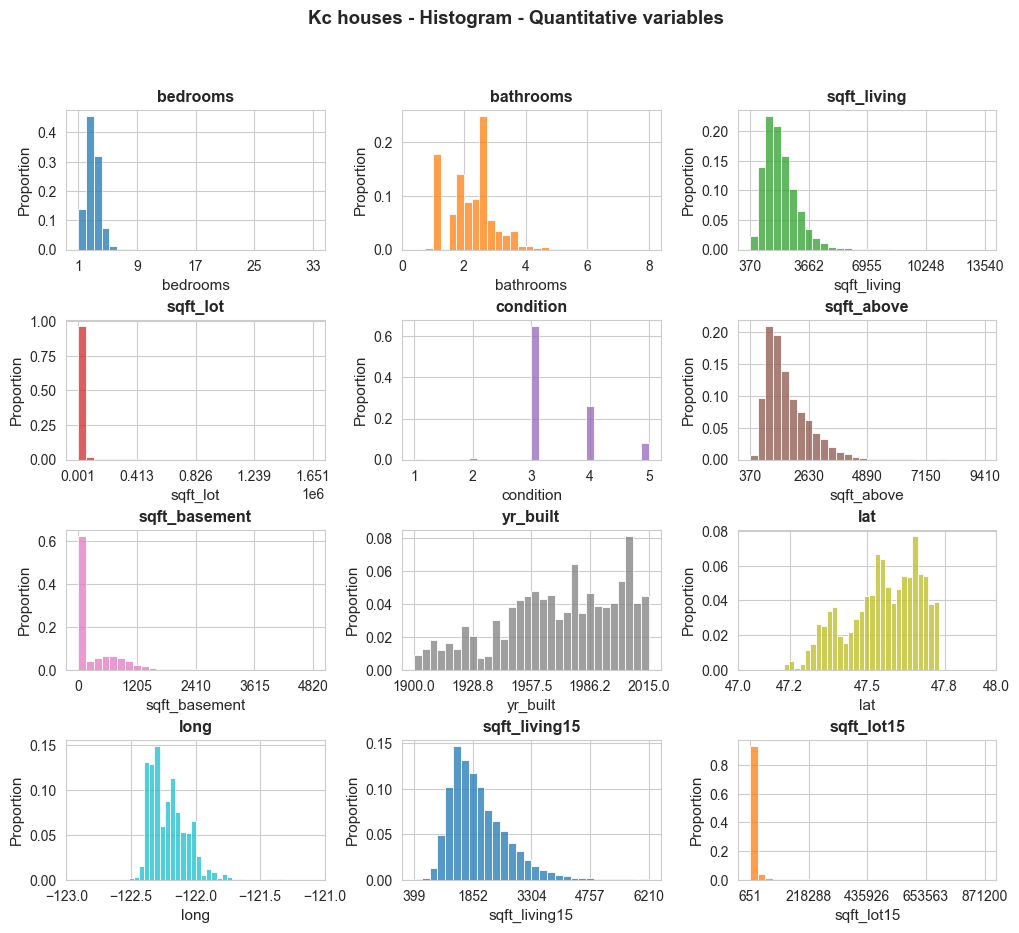

In [30]:
# Histogram
histogram_matrix(df=X, bins=30, n_cols=3, 
                 title=f'{formatted_data_name} - Histogram - Quantitative variables', 
                 figsize=(12,10), quant_col_names=quant_predictors, 
                 n_xticks=5, title_fontsize=13.5, 
                 subtitles_fontsize=11.5, save=False, file_name='', x_rotation=0, title_height=0.98,
                 style='whitegrid', hspace=0.5, wspace=0.3, n_round_xticks=1)

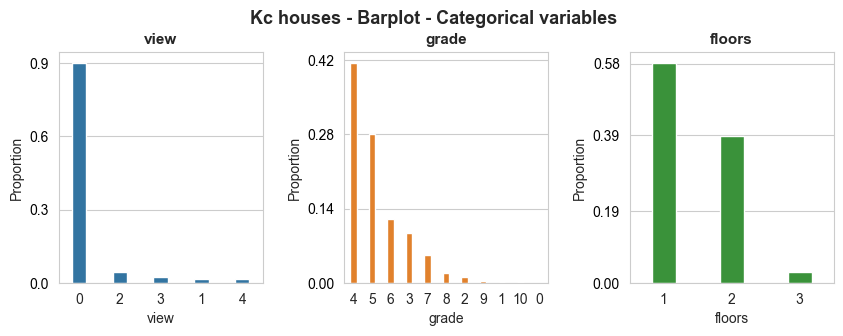

In [37]:
# Barplot
barplot_matrix(df=X, n_cols=3, 
               title=f'{formatted_data_name} - Barplot - Categorical variables', 
                 figsize=(10,3), cat_col_names=cat_predictors,
                 title_fontsize=13, subtitles_fontsize=11, 
                 save=False, file_name='', x_rotation=0, title_height=1.02,
                 style='whitegrid', hspace=0.75, wspace=0.4, title_weight='bold', bar_width=0.35,
                 ylabel_size=10, xlabel_size=10, xticks_size=10)

In [22]:
# Correlation Matrix
X[quant_predictors].corr()

bedrooms,bathrooms,sqft_living,sqft_lot,condition,sqft_above,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.514508,0.578212,0.032471,0.026496,0.479386,0.302808,0.15567,-0.009951,0.132054,0.393406,0.03069
0.514508,1.0,0.755758,0.088373,-0.126479,0.686668,0.28344,0.507173,0.02428,0.224903,0.569884,0.088303
0.578212,0.755758,1.0,0.173453,-0.059445,0.876448,0.43513,0.318152,0.052155,0.241214,0.756402,0.184342
0.032471,0.088373,0.173453,1.0,-0.00883,0.184139,0.015418,0.052946,-0.085514,0.230227,0.144763,0.718204
0.026496,-0.126479,-0.059445,-0.00883,1.0,-0.158904,0.173849,-0.361592,-0.015102,-0.105877,-0.093072,-0.003126
…,…,…,…,…,…,…,…,…,…,…,…
0.15567,0.507173,0.318152,0.052946,-0.361592,0.424037,-0.133064,1.0,-0.14837,0.409993,0.326377,0.070777
-0.009951,0.02428,0.052155,-0.085514,-0.015102,-0.001199,0.110414,-0.14837,1.0,-0.135371,0.048679,-0.086139
0.132054,0.224903,0.241214,0.230227,-0.105877,0.344842,-0.144546,0.409993,-0.135371,1.0,0.335626,0.255586


In [23]:
# Correlation Analysis
corr_matrix = X[quant_predictors].corr().to_numpy()
n_corr = len(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
n_corr_below_30 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) < 0.30)
n_corr_above_60 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) > 0.60)
n_corr_between = np.sum((np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) >= 0.30) & (np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) <= 0.60))
                        
print('Proportion of pair-wise correlation > 0.60 (in abs. value): ', np.round(n_corr_above_60 / n_corr, 2))
print('Proportion of pair-wise correlations in [0.30, 0.60]: ', np.round(n_corr_between / n_corr, 2))
print('Proportion of pair-wise correlation < 0.30 (in abs. value): ', np.round(n_corr_below_30 / n_corr, 2))

Proportion of pair-wise correlation > 0.60 (in abs. value):  0.09
Proportion of pair-wise correlations in [0.30, 0.60]:  0.23
Proportion of pair-wise correlation < 0.30 (in abs. value):  0.68


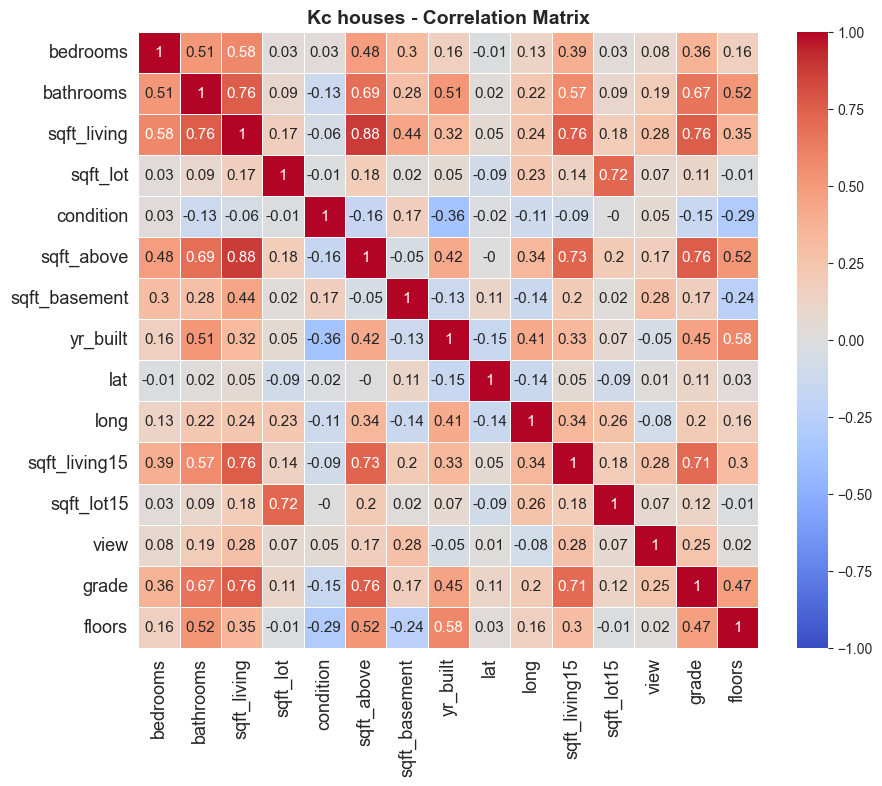

In [40]:
# Matriz de correlaciones
X_pd = X.to_pandas()
corr = X_pd.corr().round(2)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr, 
    annot=True,                 # Muestra los valores dentro de las celdas
    cmap="coolwarm",            # Paleta de colores
    vmin=-1, vmax=1,             # Escala del colorbar
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 11}      # Tamaño del texto dentro de las celdas
)

# Personalizar etiquetas
plt.xticks(fontsize=13, rotation=90)         # Tamaño etiquetas eje X
plt.yticks(fontsize=13, rotation=0)  # Tamaño etiquetas eje Y (sin rotación)
plt.title(f"{formatted_data_name} - Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()
